In [2]:
# running each line one by one to fix cloning

In [3]:
# to make the refactoring easier

In [4]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [5]:
# all imports here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import neoscore as nsc

#new s3m loader
import s3m_loader as load_s3m

import importlib
from functools import reduce
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import get_sun, SkyCoord, GCRS, GeocentricTrueEcliptic
from astroML.density_estimation import EmpiricalDistribution
from math import lgamma
import gc

from tqdm import tqdm

## ------------------------------------------------------------------------------- 

### All populations from s3m loaded in

In [6]:
s3m = load_s3m.define_s3m("mba", verbose=True)  # defaults to pop="mba"
s3m, array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m = load_s3m.s3m_array(s3m)
scorer_mba_s3m = nsc.NEOMODScorer(array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m)

Search pattern: S1_*.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./S1_00.s3m', './S1_01.s3m', './S1_02.s3m', './S1_03.s3m', './S1_04.s3m', './S1_05.s3m', './S1_06.s3m', './S1_07.s3m', './S1_08.s3m', './S1_09.s3m', './S1_10.s3m', './S1_11.s3m', './S1_12.s3m', './S1_13.s3m']
Loaded 14 file(s).
Final dataframe shape: (13883361, 15)
The final df is done.


In [7]:
neo = load_s3m.define_s3m(pop="neo")
neo, array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo = load_s3m.s3m_array(neo)
scorer_neo_s3m = nsc.NEOMODScorer(array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo)

Search pattern: S0.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./S0.s3m']
Loaded 1 file(s).
Final dataframe shape: (268511, 15)
The final df is done.


In [8]:
tno = load_s3m.define_s3m(pop="tno")
tno, array4D_tno, H_center_tno, a_center_tno, e_center_tno, i_center_tno = load_s3m.s3m_array(tno)
scorer_tno_s3m = nsc.NEOMODScorer(array4D_tno, H_center_tno, a_center_tno, e_center_tno, i_center_tno)

Search pattern: ST.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./ST.s3m']
Loaded 1 file(s).
Final dataframe shape: (48682, 15)
The final df is done.


In [9]:
trojan = load_s3m.define_s3m(pop="trojan")
trojan,array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn = load_s3m.s3m_array(trojan)
scorer_tjn_s3m = nsc.NEOMODScorer(array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn)

Search pattern: St5.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./St5.s3m']
Loaded 1 file(s).
Final dataframe shape: (179882, 15)
The final df is done.


## ------------------------------------------------------------------------------- 

In [15]:
#  Global variables 
obstime_str = "2025-03-21T00:00:00"
t_obs = Time(obstime_str, scale="tdb")
max_sep_deg = 30.0
AU_km = 149_597_870.7
mu_sun = 1.32712440018e11

### section to compute apparent magnitude for full population on the full sky

In [16]:
def compute_apparent_magnitude_for_population(
    df,
    obstime_str,
    scorer,
    chunk=100_000,
    show_progress=False,
):
    """
    Compute apparent magnitude for every object in the full population df
    at obstime_str, BEFORE any sky-position cut.
    """

    AU_KM = 149597870.7

    # propagate all rows in df
    r_ecl, v_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=df["a"].to_numpy(dtype=float),
        e=df["e"].to_numpy(dtype=float),
        inc_deg=df["i"].to_numpy(dtype=float),
        raan_deg=df["node"].to_numpy(dtype=float),
        argp_deg=df["argperi"].to_numpy(dtype=float),
        tp_mjd=df["t_p"].to_numpy(dtype=float),
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    # rotate ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_eq = np.column_stack([
        r_ecl[:, 0],
        c * r_ecl[:, 1] - s * r_ecl[:, 2],
        s * r_ecl[:, 1] + c * r_ecl[:, 2],
    ])

    # Earth heliocentric state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    r_helio_vec = r_eq
    r_obs_vec = r_eq - (rE + r_tele)
    
    r_sun = np.linalg.norm(r_helio_vec, axis=1)
    Delta = np.linalg.norm(r_obs_vec, axis=1)
    
    if np.nanmedian(r_sun) > 1000:
        r_sun = r_sun / AU_KM
        Delta = Delta / AU_KM
    
    u_sun = -r_helio_vec / np.linalg.norm(r_helio_vec, axis=1, keepdims=True)
    u_obs = -r_obs_vec / np.linalg.norm(r_obs_vec, axis=1, keepdims=True)

    cos_alpha = np.sum(u_sun * u_obs, axis=1)
    cos_alpha = np.clip(cos_alpha, -1.0, 1.0)
    alpha = np.arccos(cos_alpha)

    # HG phase function
    G = 0.15
    A1, A2, B1, B2 = 3.33, 1.87, 0.63, 1.22
    phi1 = np.exp(-A1 * np.tan(0.5 * alpha)**B1)
    phi2 = np.exp(-A2 * np.tan(0.5 * alpha)**B2)
    Phi = (1 - G) * phi1 + G * phi2
    Phi = np.maximum(Phi, 1e-30)

    H = df["H"].to_numpy(dtype=float)

    mag_app = H + 5.0 * np.log10(r_sun * Delta) - 2.5 * np.log10(Phi)
    return mag_app

In [17]:
def select_df_by_mag_bin(df, mag_app, mag_min=None, mag_max=None):
    """
    Select rows directly from the full population df using apparent magnitude.
    """
    sel = np.isfinite(mag_app)

    if mag_min is not None:
        sel &= (mag_app >= mag_min)

    if mag_max is not None:
        sel &= (mag_app < mag_max)

    df_sel = df.loc[sel].copy()
    mag_sel = mag_app[sel]

    return df_sel, mag_sel
    # df_sel here is magnitude filtered but whole sky

## ------------------------------------------------------------------------------- 

### helper functions
#### so mean_anomaly_deg_at_obstime and mean_longitude_deg_at_obstime are not doing anything for the cloner — they are purely for annotating visible_df with M_obs_deg and L_obs_deg columns. Those columns end up in visible_df and are available for diagnostics and plots (e.g. checking the phase distribution of the visible subset), but the cloner recomputes M_obs itself from scratch from t_p and a so it does not actually read those columns.

#### build_visible_subset_dataframe calls them to annotate the output dataframe.

In [18]:
def wrap360_deg(x):
    return np.mod(x, 360.0)

def mean_anomaly_deg_at_obstime(a_AU, tp_mjd, obstime_str):
    t_obs = Time(obstime_str, scale="tdb")
    a_AU = np.asarray(a_AU, dtype=float)
    tp_mjd = np.asarray(tp_mjd, dtype=float)
    a_km = a_AU * AU_km
    n_rad_s = np.sqrt(mu_sun / a_km**3)
    n_rad_day = n_rad_s * 86400.0
    M_rad = n_rad_day * (t_obs.mjd - tp_mjd)
    return wrap360_deg(np.rad2deg(M_rad))

def mean_longitude_deg_at_obstime(a_AU, node_deg, argperi_deg, tp_mjd, obstime_str):
    M_deg = mean_anomaly_deg_at_obstime(a_AU, tp_mjd, obstime_str)
    return wrap360_deg(node_deg + argperi_deg + M_deg)

### Sky patch cut and orbital phase

In [19]:
# lets see if this fixes bug
def build_visible_subset_dataframe(
    df,
    obstime_str,
    scorer,
    max_sep_deg=30.0,
    chunk=100_000,
    show_progress=True,
    center_mode="custom_ecliptic",
    center_lon_deg=180.0,
    center_lat_deg=0.0,
):
    """
    Propagate the ORIGINAL dataframe to obstime_str, apply the sky cut,
    and return a dataframe of only the objects that survive.

    Adds:
        M_obs_deg
        L_obs_deg
        ra_deg
        dec_deg
        dra_deg_day
        ddec_deg_day
        vlam
        vbeta
        sky_sep_deg
    """
    t_obs = Time(obstime_str, scale="tdb")

    # original row indices so we can map mask -> dataframe rows
    orig_idx = np.arange(len(df), dtype=int)

    # orbital elements from dataframe
    a_AU = df["a"].to_numpy(dtype=float)
    e = df["e"].to_numpy(dtype=float)
    inc = df["i"].to_numpy(dtype=float)
    raan = df["node"].to_numpy(dtype=float)
    argp = df["argperi"].to_numpy(dtype=float)
    tp_mjd = df["t_p"].to_numpy(dtype=float)

    # heliocentric ecliptic state from existing pipeline
    r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=a_AU,
        e=e,
        inc_deg=inc,
        raan_deg=raan,
        argp_deg=argp,
        tp_mjd=tp_mjd,
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    # ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_obj_helio = np.column_stack([
        r_obj_ecl[:, 0],
        c * r_obj_ecl[:, 1] - s * r_obj_ecl[:, 2],
        s * r_obj_ecl[:, 1] + c * r_obj_ecl[:, 2],
    ])

    v_obj_helio = np.column_stack([
        v_obj_ecl[:, 0],
        c * v_obj_ecl[:, 1] - s * v_obj_ecl[:, 2],
        s * v_obj_ecl[:, 1] + c * v_obj_ecl[:, 2],
    ])

    # observer state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    # topocentric relative vectors
    r_rel = r_obj_helio - (rE + r_tele)
    v_rel = v_obj_helio - vE

    # RA/Dec and rates in equatorial frame
    x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x * x + y * y
    r2 = rho2 + z * z
    rho = np.sqrt(rho2)

    ra = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    dra = (x * vy - y * vx) / rho2
    ddec = (vz * rho2 - z * (x * vx + y * vy)) / (r2 * rho)

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        np.isfinite(rho2) & (rho2 > 0) &
        np.isfinite(r2) & (r2 > 0) &
        np.isfinite(rho) & (rho > 0)
    )

    orig_idx_good = orig_idx[good]

    ra_deg = np.rad2deg(ra[good]) % 360.0
    dec_deg = np.rad2deg(dec[good])
    dra_deg_day = np.rad2deg(dra[good]) * 86400.0
    ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

    sc = SkyCoord(
        ra=ra_deg * u.deg,
        dec=dec_deg * u.deg,
        frame=GCRS(obstime=t_obs),
    )

    if center_mode == "antisun":
        sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
        center_sc = SkyCoord(
            x=-sun_gcrs.cartesian.x,
            y=-sun_gcrs.cartesian.y,
            z=-sun_gcrs.cartesian.z,
            representation_type="cartesian",
            frame=GCRS(obstime=t_obs),
        )
    elif center_mode == "custom_ecliptic":
        center_ecl = SkyCoord(
            lon=center_lon_deg * u.deg,
            lat=center_lat_deg * u.deg,
            distance=1.0 * u.AU,
            frame=GeocentricTrueEcliptic(obstime=t_obs),
        )
        center_sc = center_ecl.transform_to(GCRS(obstime=t_obs))
    else:
        raise ValueError("center_mode must be 'antisun' or 'custom_ecliptic'")

    sky_sep_deg = sc.separation(center_sc).deg
    m = sky_sep_deg <= max_sep_deg

    # selected rows in original dataframe
    sel_idx = orig_idx_good[m]
    out = df.iloc[sel_idx].copy().reset_index(drop=True)

    out["ra_deg"] = ra_deg[m]
    out["dec_deg"] = dec_deg[m]
    out["dra_deg_day"] = dra_deg_day[m]
    out["ddec_deg_day"] = ddec_deg_day[m]
    out["sky_sep_deg"] = sky_sep_deg[m]

    # selected relative state vectors in equatorial frame
    r_rel_sel = r_rel[good][m]
    v_rel_sel = v_rel[good][m]

    # rotate equatorial -> ecliptic
    x_ecl = r_rel_sel[:, 0]
    y_ecl = c * r_rel_sel[:, 1] + s * r_rel_sel[:, 2]
    z_ecl = -s * r_rel_sel[:, 1] + c * r_rel_sel[:, 2]

    vx_ecl = v_rel_sel[:, 0]
    vy_ecl = c * v_rel_sel[:, 1] + s * v_rel_sel[:, 2]
    vz_ecl = -s * v_rel_sel[:, 1] + c * v_rel_sel[:, 2]

    rho2_ecl = x_ecl * x_ecl + y_ecl * y_ecl
    r2_ecl = rho2_ecl + z_ecl * z_ecl
    rho_ecl = np.sqrt(rho2_ecl)

    lam = np.arctan2(y_ecl, x_ecl)
    beta = np.arctan2(z_ecl, rho_ecl)

    dlam = (x_ecl * vy_ecl - y_ecl * vx_ecl) / rho2_ecl
    dbeta = (vz_ecl * rho2_ecl - z_ecl * (x_ecl * vx_ecl + y_ecl * vy_ecl)) / (r2_ecl * rho_ecl)

    out["lam_deg"] = np.rad2deg(lam) % 360.0
    out["beta_deg"] = np.rad2deg(beta)
    out["vlam"] = np.rad2deg(dlam) * 86400.0
    out["vbeta"] = np.rad2deg(dbeta) * 86400.0

    # phase like quantities at this obstime
    out["M_obs_deg"] = mean_anomaly_deg_at_obstime(
        out["a"].to_numpy(),
        out["t_p"].to_numpy(),
        obstime_str,
    )

    out["L_obs_deg"] = mean_longitude_deg_at_obstime(
        out["a"].to_numpy(),
        out["node"].to_numpy(),
        out["argperi"].to_numpy(),
        out["t_p"].to_numpy(),
        obstime_str,
    )

    return out

### cloning w mean anomaly randomisation using astroml 

In [20]:
# always pass df_sel (for mag cut) or out (the output of build_visible_subset_dataframe) not the full raw pop. 
def clone_population_random_mean_anomaly(df, clone_factor, obstime_str, rng=None):
    """
    Clone each orbit clone_factor times using an astroML-style empirical
    distribution of mean anomaly M(obstime) measured from the input subset.

    The sampled mean anomalies are restricted to the min/max range of the
    subset after circular unwrapping.

    Returns
    -------
    a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_out
    """
    if rng is None:
        rng = np.random.default_rng(0)

    t_obs = Time(obstime_str, scale="tdb")

    # always using a directly from df
    a_AU = df["a"].to_numpy(dtype=np.float64)
    e = df["e"].to_numpy(dtype=np.float32)
    inc = df["i"].to_numpy(dtype=np.float32)
    raan = df["node"].to_numpy(dtype=np.float32)
    argp = df["argperi"].to_numpy(dtype=np.float32)
    tp = df["t_p"].to_numpy(dtype=np.float64)

    # repeat fixed elements
    a_rep = np.repeat(a_AU, clone_factor).astype(np.float64)
    e_rep = np.repeat(e, clone_factor).astype(np.float32)
    inc_rep = np.repeat(inc, clone_factor).astype(np.float32)
    raan_rep = np.repeat(raan, clone_factor).astype(np.float32)
    argp_rep = np.repeat(argp, clone_factor).astype(np.float32)

    # mean motion in rad/day
    a_km = a_AU * AU_km
    n_rad_s = np.sqrt(mu_sun / (a_km ** 3))
    n_rad_day = n_rad_s * 86400.0

    # observed/df mean anomaly at obstime
    M_obs = np.mod((t_obs.mjd - tp) * n_rad_day, 2.0 * np.pi)

    # shift the circular distribution so it is not split at 0 / 2pi
    mean_angle = np.mod(np.angle(np.mean(np.exp(1j * M_obs))), 2.0 * np.pi)
    M_shift = np.mod(M_obs - mean_angle, 2.0 * np.pi)

    # subset support in shifted coordinates
    M_min = M_shift.min()
    M_max = M_shift.max()

    # empirical clone in shifted coordinates
    # astroML expects shape (N, D), so use [:, None]
    M_shift_clone = EmpiricalDistribution(M_shift).rvs(len(a_rep))

    # enforce sampled support to stay inside subset min/max
    M_shift_clone = np.clip(M_shift_clone, M_min, M_max)

    # wrap back to [0, 2pi)
    M_clone = np.mod(M_shift_clone + mean_angle, 2.0 * np.pi)

    # repeat mean motion for cloned sample
    n_rep = np.repeat(n_rad_day, clone_factor)

    # choose t_p so that M(obstime) = M_clone
    tp_out = (t_obs.mjd - (M_clone / n_rep)).astype(np.float32)

    return (
        a_rep.astype(np.float32),
        e_rep,
        inc_rep,
        raan_rep,
        argp_rep,
        tp_out,
    )

In [21]:
# build trojan_visible (sky-cut subset)


from astropy.time import Time
import astropy.units as u
from astropy.coordinates import SkyCoord, GCRS, GeocentricTrueEcliptic

obstime_str = "2025-03-21T00:00:00"
t_obs = Time(obstime_str, scale="tdb")
max_sep_deg = 30.0
AU_km = 149_597_870.7
mu_sun = 1.32712440018e11

trojan_visible = build_visible_subset_dataframe(
    trojan,
    obstime_str=obstime_str,
    scorer=scorer_tjn_s3m,
    max_sep_deg=max_sep_deg,
    center_mode="custom_ecliptic",
    center_lon_deg=180.0,
    center_lat_deg=0.0,
)
print("Visible Trojans in patch:", len(trojan_visible))
print("M_obs range (deg):", trojan_visible["M_obs_deg"].min(), "to", trojan_visible["M_obs_deg"].max())
print("L_obs range (deg):", trojan_visible["L_obs_deg"].min(), "to", trojan_visible["L_obs_deg"].max())

Propagate with newton: 100%|██████████| 2/2 [00:00<00:00, 17.65it/s]


Visible Trojans in patch: 23605
M_obs range (deg): 0.010989641358264635 to 359.9620525065643
L_obs range (deg): 133.0863165391247 to 190.96715657394589


M_obs shape: (23605,)
M_obs min: 0.010989641358155961 deg
M_obs max: 359.9620525065642 deg
Any outside [0,2pi]? False


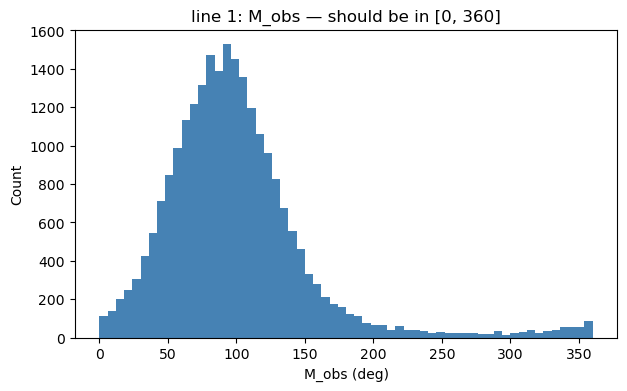

In [30]:
df = trojan_visible  # the sky-cut subset
clone_factor = 10

a_AU = df["a"].to_numpy(dtype=np.float64)
e    = df["e"].to_numpy(dtype=np.float32)
inc  = df["i"].to_numpy(dtype=np.float32)
raan = df["node"].to_numpy(dtype=np.float32)
argp = df["argperi"].to_numpy(dtype=np.float32)
tp   = df["t_p"].to_numpy(dtype=np.float64)

a_rep    = np.repeat(a_AU, clone_factor).astype(np.float64)
e_rep    = np.repeat(e,    clone_factor).astype(np.float32)
inc_rep  = np.repeat(inc,  clone_factor).astype(np.float32)
raan_rep = np.repeat(raan, clone_factor).astype(np.float32)
argp_rep = np.repeat(argp, clone_factor).astype(np.float32)

a_km      = a_AU * AU_km
n_rad_s   = np.sqrt(mu_sun / (a_km ** 3))
n_rad_day = n_rad_s * 86400.0

# line 1
M_obs = np.mod((t_obs.mjd - tp) * n_rad_day, 2.0 * np.pi)

print("M_obs shape:", M_obs.shape)
print("M_obs min:", np.rad2deg(M_obs.min()), "deg")
print("M_obs max:", np.rad2deg(M_obs.max()), "deg")
print("Any outside [0,2pi]?", np.any(M_obs < 0) or np.any(M_obs > 2*np.pi))

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(np.rad2deg(M_obs), bins=60, color='steelblue')
ax.set_xlabel("M_obs (deg)"); ax.set_ylabel("Count")
ax.set_title("line 1: M_obs — should be in [0, 360]")
plt.show()

mean_angle: 91.04564687575045 deg
Expected: roughly the peak of M_obs histogram above


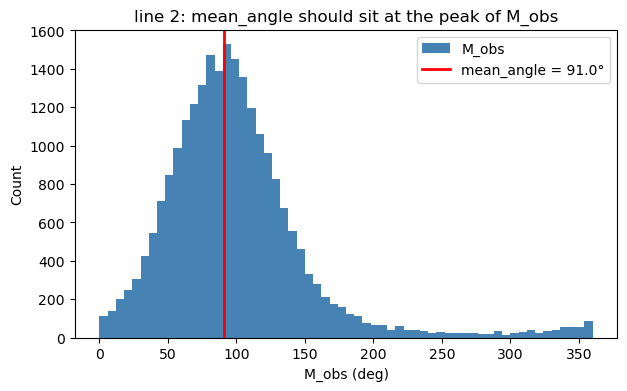

In [31]:
# line 2
mean_angle = np.mod(np.angle(np.mean(np.exp(1j * M_obs))), 2.0 * np.pi)

print("mean_angle:", np.rad2deg(mean_angle), "deg")
print("Expected: roughly the peak of M_obs histogram above")

# plot M_obs with mean_angle marked
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(np.rad2deg(M_obs), bins=60, color='steelblue', label='M_obs')
ax.axvline(np.rad2deg(mean_angle), color='red', lw=2, label=f'mean_angle = {np.rad2deg(mean_angle):.1f}°')
ax.set_xlabel("M_obs (deg)"); ax.set_ylabel("Count")
ax.set_title("line 2: mean_angle should sit at the peak of M_obs")
ax.legend()
plt.show()

M_shift min: 0.001724334865778619 deg
M_shift max: 359.99980519012837 deg
M_shift range: 359.9980808552626 deg


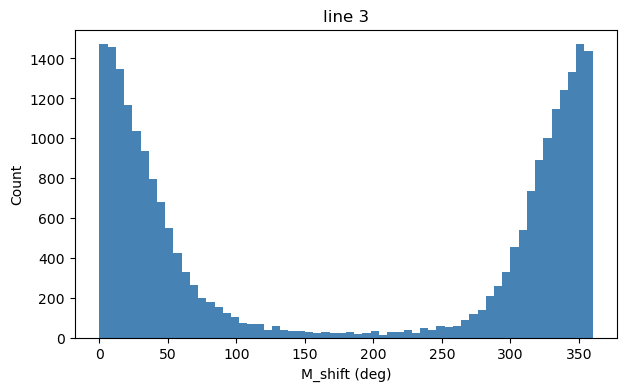

In [32]:
# line 3
M_shift = np.mod(M_obs - mean_angle, 2.0 * np.pi)

print("M_shift min:", np.rad2deg(M_shift.min()), "deg")
print("M_shift max:", np.rad2deg(M_shift.max()), "deg")
print("M_shift range:", np.rad2deg(M_shift.max() - M_shift.min()), "deg")


fig, ax = plt.subplots(figsize=(7,4))
ax.hist(np.rad2deg(M_shift), bins=60, color='steelblue')
ax.set_xlabel("M_shift (deg)"); ax.set_ylabel("Count")
ax.set_title("line 3")
plt.show()

In [33]:
# lines 4-5
M_min = M_shift.min()
M_max = M_shift.max()

print("M_min:", np.rad2deg(M_min), "deg")
print("M_max:", np.rad2deg(M_max), "deg")
print("Clip window width:", np.rad2deg(M_max - M_min), "deg")
print(">>> If this is ~360, clip doesnt do anything <<<")

M_min: 0.001724334865778619 deg
M_max: 359.99980519012837 deg
Clip window width: 359.9980808552626 deg
>>> If this is ~360, clip doesnt do anything <<<


M_shift_clone shape: (236050,)
M_shift_clone min: 0.0017949605648989412 deg
M_shift_clone max: 359.9980628252031 deg


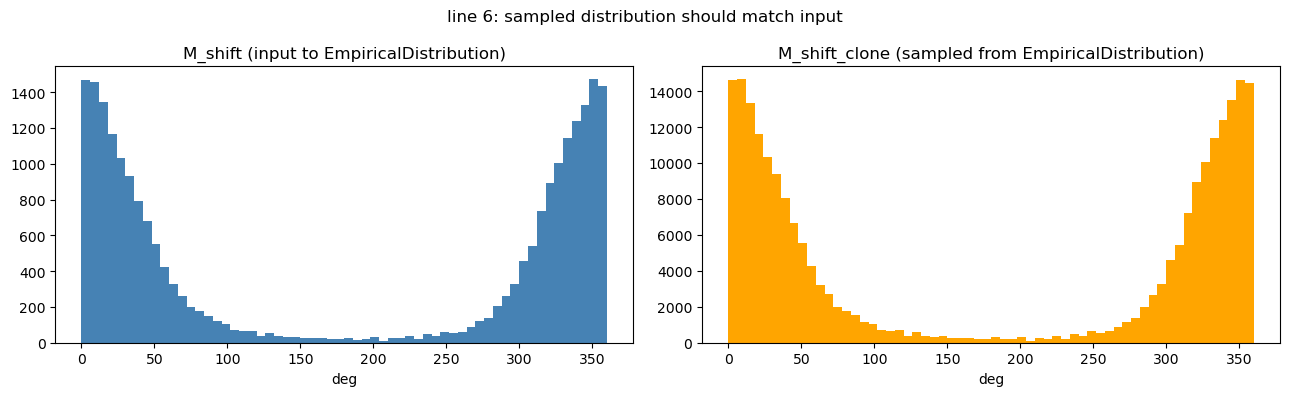

In [34]:
# line 6
M_shift_clone = EmpiricalDistribution(M_shift).rvs(len(a_rep))

print("M_shift_clone shape:", M_shift_clone.shape)
print("M_shift_clone min:", np.rad2deg(M_shift_clone.min()), "deg")
print("M_shift_clone max:", np.rad2deg(M_shift_clone.max()), "deg")

fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].hist(np.rad2deg(M_shift), bins=60, color='steelblue')
axes[0].set_title("M_shift (input to EmpiricalDistribution)")
axes[0].set_xlabel("deg")
axes[1].hist(np.rad2deg(M_shift_clone), bins=60, color='orange')
axes[1].set_title("M_shift_clone (sampled from EmpiricalDistribution)")
axes[1].set_xlabel("deg")
plt.suptitle("line 6: sampled distribution should match input")
plt.tight_layout()
plt.show()

In [35]:
# line 7
before_clip = M_shift_clone.copy()
M_shift_clone = np.clip(M_shift_clone, M_min, M_max)

n_clipped = np.sum(before_clip != M_shift_clone)
print(f"Values changed by clip: {n_clipped} out of {len(M_shift_clone)}")
print(">>> If 0, clip is doing nothing as M_min/M_max span full circle <<<")

Values changed by clip: 0 out of 236050
>>> If 0, clip is doing nothing as M_min/M_max span full circle <<<


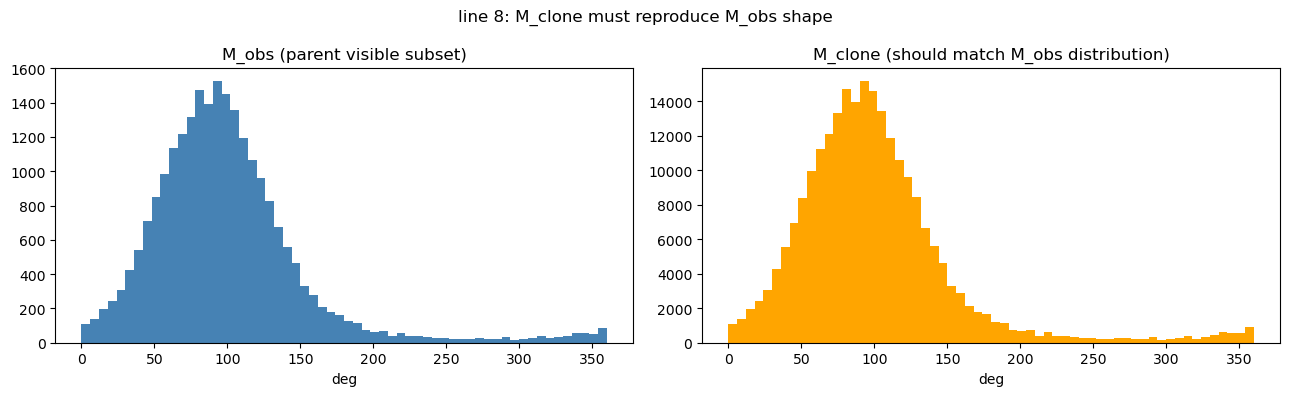

In [36]:
# line 8
M_clone = np.mod(M_shift_clone + mean_angle, 2.0 * np.pi)

fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].hist(np.rad2deg(M_obs), bins=60, color='steelblue')
axes[0].set_title("M_obs (parent visible subset)")
axes[0].set_xlabel("deg")
axes[1].hist(np.rad2deg(M_clone), bins=60, color='orange')
axes[1].set_title("M_clone (should match M_obs distribution)")
axes[1].set_xlabel("deg")
plt.suptitle("line 8: M_clone must reproduce M_obs shape")
plt.tight_layout()
plt.show()

M residual max (deg): 0.00016901708032319933
M residual mean (deg): 8.182531930324421e-05


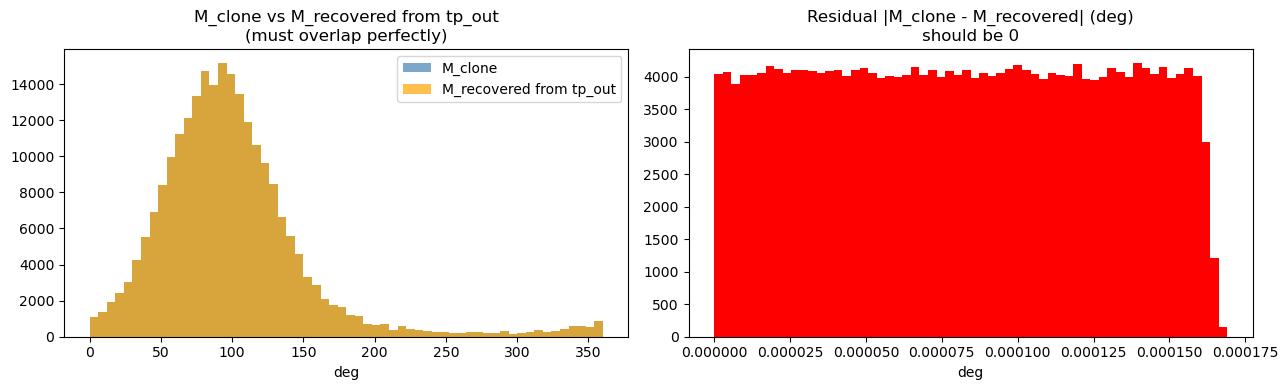

In [38]:
# lines 9-10
n_rep = np.repeat(n_rad_day, clone_factor)
tp_out = (t_obs.mjd - (M_clone / n_rep)).astype(np.float32)  

# get M from tp_out should match M_clone exactly
M_recovered = np.mod((t_obs.mjd - tp_out.astype(np.float64)) * n_rep, 2.0 * np.pi)

residual_deg = np.rad2deg(np.abs(M_recovered - M_clone))
print("M residual max (deg):", residual_deg.max())
print("M residual mean (deg):", residual_deg.mean())


fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].hist(np.rad2deg(M_clone), bins=60, color='steelblue', label='M_clone', alpha=0.7)
axes[0].hist(np.rad2deg(M_recovered), bins=60, color='orange', label='M_recovered from tp_out', alpha=0.7)
axes[0].set_title("M_clone vs M_recovered from tp_out\n(must overlap perfectly)")
axes[0].legend(); axes[0].set_xlabel("deg")
axes[1].hist(residual_deg, bins=60, color='red')
axes[1].set_title("Residual |M_clone - M_recovered| (deg)\nshould be 0")
axes[1].set_xlabel("deg")
plt.tight_layout()
plt.show()

In [39]:
L_clone = mean_longitude_deg_at_obstime(
    a_rep, raan_rep, argp_rep, tp_out, obstime_str
)

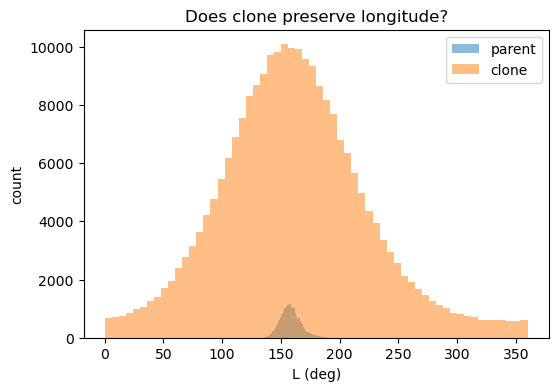

In [40]:
plt.figure(figsize=(6,4))
plt.hist(trojan_visible["L_obs_deg"], bins=60, alpha=0.5, label="parent")
plt.hist(L_clone, bins=60, alpha=0.5, label="clone")
plt.xlabel("L (deg)")
plt.ylabel("count")
plt.title("Does clone preserve longitude?")
plt.legend()
plt.show()

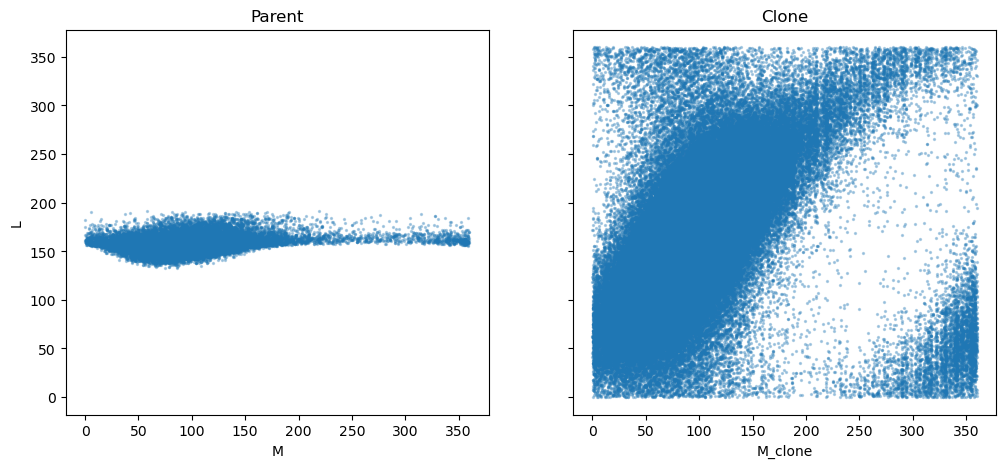

In [41]:
fig, axes = plt.subplots(1,2, figsize=(12,5), sharex=True, sharey=True)

axes[0].scatter(
    trojan_visible["M_obs_deg"],
    trojan_visible["L_obs_deg"],
    s=2, alpha=0.3
)
axes[0].set_title("Parent")
axes[0].set_xlabel("M")
axes[0].set_ylabel("L")

axes[1].scatter(
    np.rad2deg(M_clone),
    L_clone,
    s=2, alpha=0.3
)
axes[1].set_title("Clone")
axes[1].set_xlabel("M_clone")

plt.show()

In [43]:
# plot M vs (omega + argperi)

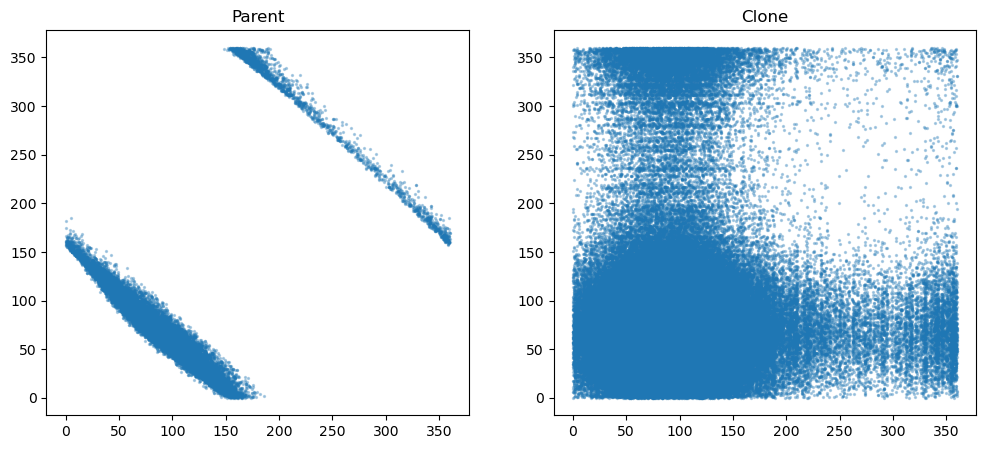

In [44]:
K_parent = (trojan_visible["node"] + trojan_visible["argperi"]) % 360
K_clone  = (raan_rep + argp_rep) % 360

fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].scatter(
    trojan_visible["M_obs_deg"], K_parent,
    s=2, alpha=0.3
)
axes[0].set_title("Parent")

axes[1].scatter(
    np.rad2deg(M_clone), K_clone,
    s=2, alpha=0.3
)
axes[1].set_title("Clone")

plt.show()

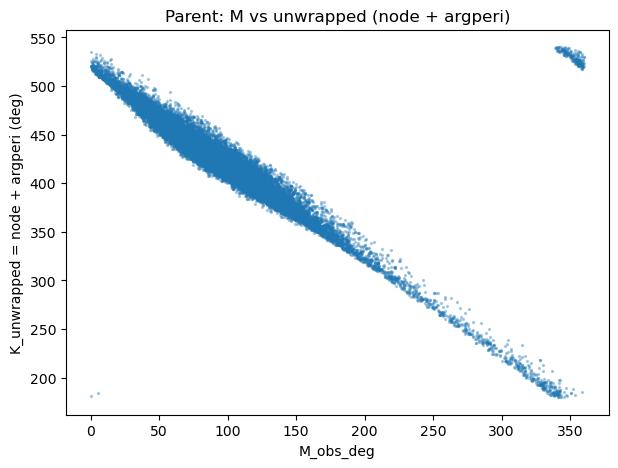

In [58]:
# parent variables
M_parent = trojan_visible["M_obs_deg"].to_numpy()
K_parent = (trojan_visible["node"].to_numpy() + trojan_visible["argperi"].to_numpy()) % 360.0

# unwrap lower branch by adding 360

K_parent_unwrapped = K_parent.copy()
K_parent_unwrapped[K_parent_unwrapped < 180.0] += 360.0

plt.figure(figsize=(7,5))
plt.scatter(M_parent, K_parent_unwrapped, s=2, alpha=0.3)
plt.xlabel("M_obs_deg")
plt.ylabel("K_unwrapped = node + argperi (deg)")
plt.title("Parent: M vs unwrapped (node + argperi)")
plt.show()

In [46]:
def sample_conditional_K_from_M(
    M_parent_deg,
    K_parent_deg,
    M_clone_deg,
    bin_width_deg=10.0,
    unwrap_threshold_deg=180.0,
    rng=None,
):
    """
    Sample K = (node + argperi) conditionally on M using parent data.

    Steps:
      1. unwrap K by adding 360 to the lower branch
      2. bin parent data in M
      3. for each clone M, sample K from the parent points in that M bin
      4. wrap sampled K back to [0, 360)

    Returns
    -------
    K_clone_deg : ndarray
        Sampled wrapped K values in [0, 360)
    K_clone_unwrapped_deg : ndarray
        Sampled unwrapped K values, useful for diagnostics
    """
    if rng is None:
        rng = np.random.default_rng(0)

    M_parent_deg = np.asarray(M_parent_deg, dtype=float)
    K_parent_deg = np.asarray(K_parent_deg, dtype=float)
    M_clone_deg = np.asarray(M_clone_deg, dtype=float)

    # unwrap parent K
    K_parent_unwrapped = K_parent_deg.copy()
    K_parent_unwrapped[K_parent_unwrapped < unwrap_threshold_deg] += 360.0

    # M bins
    edges = np.arange(0.0, 360.0 + bin_width_deg, bin_width_deg)
    nbins = len(edges) - 1

    # parent bin index
    parent_bin = np.digitize(M_parent_deg, edges) - 1
    parent_bin = np.clip(parent_bin, 0, nbins - 1)

    # store parent K values in each M bin
    K_by_bin = [K_parent_unwrapped[parent_bin == i] for i in range(nbins)]

    # identify non-empty bins so we can fall back to nearest one if needed
    nonempty = np.array([len(v) > 0 for v in K_by_bin])
    nonempty_idx = np.where(nonempty)[0]

    # clone bin index
    clone_bin = np.digitize(M_clone_deg, edges) - 1
    clone_bin = np.clip(clone_bin, 0, nbins - 1)

    K_clone_unwrapped = np.empty_like(M_clone_deg, dtype=float)

    for j, b in enumerate(clone_bin):
        if len(K_by_bin[b]) == 0:
            # fallback: use nearest non-empty bin
            nearest = nonempty_idx[np.argmin(np.abs(nonempty_idx - b))]
            draw_from = K_by_bin[nearest]
        else:
            draw_from = K_by_bin[b]

        K_clone_unwrapped[j] = rng.choice(draw_from)

    K_clone_deg = K_clone_unwrapped % 360.0
    return K_clone_deg, K_clone_unwrapped

In [59]:
# current clone M from cloner
M_clone_deg = mean_anomaly_deg_at_obstime(a_rep, tp_out, obstime_str)

# parent relation
M_parent = trojan_visible["M_obs_deg"].to_numpy()
K_parent = (trojan_visible["node"].to_numpy() + trojan_visible["argperi"].to_numpy()) % 360.0

# sample K conditionally on M_clone
K_clone_deg, K_clone_unwrapped = sample_conditional_K_from_M(
    M_parent_deg=M_parent,
    K_parent_deg=K_parent,
    M_clone_deg=M_clone_deg,
    bin_width_deg=10.0,
    unwrap_threshold_deg=180.0,
    rng=np.random.default_rng(701),
)

In [48]:
raan_new = raan_rep.copy()
argp_new = (K_clone_deg - raan_new) % 360.0

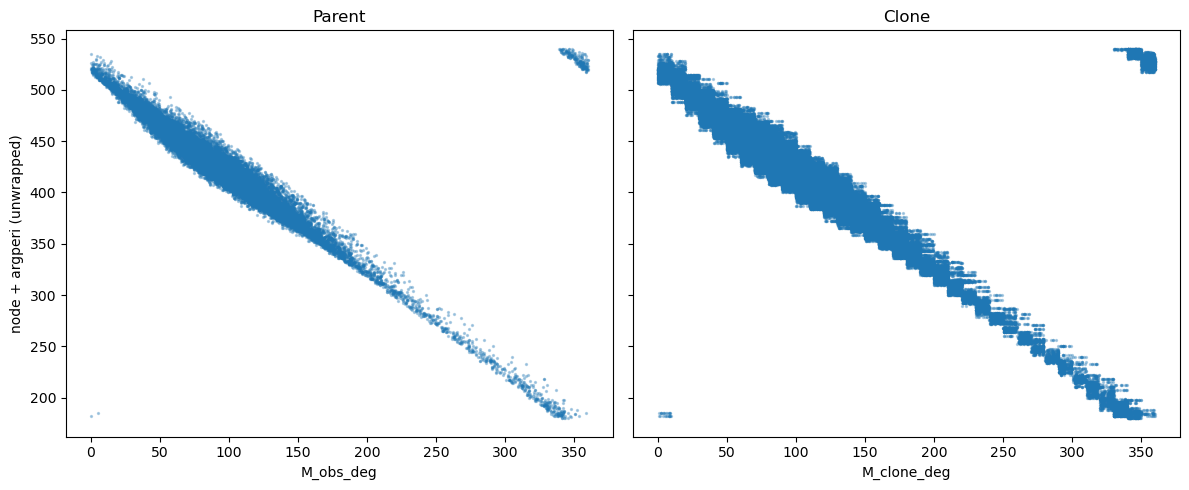

In [49]:
K_clone_check = (raan_new + argp_new) % 360.0
K_clone_check_unwrapped = K_clone_check.copy()
K_clone_check_unwrapped[K_clone_check_unwrapped < 180.0] += 360.0

fig, axes = plt.subplots(1, 2, figsize=(12,5), sharex=True, sharey=True)

K_parent_unwrapped = K_parent.copy()
K_parent_unwrapped[K_parent_unwrapped < 180.0] += 360.0

axes[0].scatter(M_parent, K_parent_unwrapped, s=2, alpha=0.3)
axes[0].set_title("Parent")
axes[0].set_xlabel("M_obs_deg")
axes[0].set_ylabel("node + argperi (unwrapped)")

axes[1].scatter(M_clone_deg, K_clone_check_unwrapped, s=2, alpha=0.3)
axes[1].set_title("Clone")
axes[1].set_xlabel("M_clone_deg")

plt.tight_layout()
plt.show()

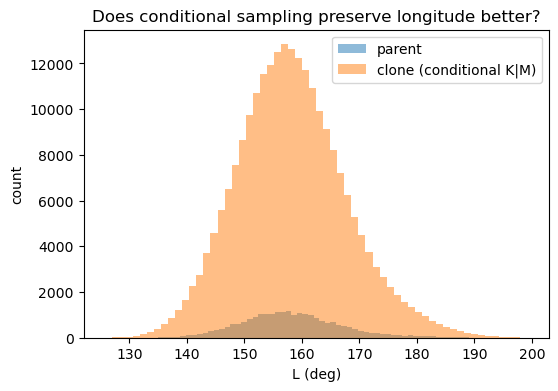

In [50]:
L_clone_new = mean_longitude_deg_at_obstime(
    a_rep, raan_new, argp_new, tp_out, obstime_str
)

plt.figure(figsize=(6,4))
plt.hist(trojan_visible["L_obs_deg"], bins=60, alpha=0.5, label="parent")
plt.hist(L_clone_new, bins=60, alpha=0.5, label="clone (conditional K|M)")
plt.xlabel("L (deg)")
plt.ylabel("count")
plt.title("Does conditional sampling preserve longitude better?")
plt.legend()
plt.show()

In [52]:
def elements_to_heliocentric_xy(
    a_AU, e, inc, raan, argp, tp_mjd,
    obstime_str,
    chunk=100_000,
    show_progress=True,
    output_in_au=True,
):
    """
    Convert orbital elements to heliocentric ecliptic X,Y at obstime_str.
    Returns X, Y in AU (or km if output_in_au=False).
    """
    r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=a_AU, e=e, inc_deg=inc, raan_deg=raan,
        argp_deg=argp, tp_mjd=tp_mjd,
        obstime_str=obstime_str, method="newton",
        n_iter=10, chunk=chunk, show_progress=show_progress,
    )
    x = np.asarray(r_obj_ecl[:, 0], dtype=np.float64)
    y = np.asarray(r_obj_ecl[:, 1], dtype=np.float64)
    finite = np.isfinite(x) & np.isfinite(y)
    x, y = x[finite], y[finite]
    if output_in_au:
        x = x / AU_km
        y = y / AU_km
    return x.astype(np.float32), y.astype(np.float32)

In [54]:
def plot_heliocentric_xy(x, y, title="Heliocentric ecliptic X-Y",
                         max_points=100_000, seed=123, xy_max_au=8.0):
    rng = np.random.default_rng(seed)
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    if len(x) > max_points:
        idx = rng.choice(len(x), size=max_points, replace=False)
        x, y = x[idx], y[idx]
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(x, y, s=2, alpha=0.35)
    ax.scatter([0], [0], s=80, marker="o")  # Sun
    ax.axhline(0, lw=1); ax.axvline(0, lw=1)
    ax.set_xlabel("Heliocentric ecliptic X (AU)")
    ax.set_ylabel("Heliocentric ecliptic Y (AU)")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-xy_max_au, xy_max_au); ax.set_ylim(-xy_max_au, xy_max_au)
    plt.show()

def plot_xy_comparison(x1, y1, x2, y2, title1, title2,
                         xy_max_au=8.0, max_points=100_000, seed=123):
    rng = np.random.default_rng(seed)
    def sub(x, y):
        if len(x) > max_points:
            idx = rng.choice(len(x), size=max_points, replace=False)
            return x[idx], y[idx]
        return x, y
    x1, y1 = sub(np.asarray(x1), np.asarray(y1))
    x2, y2 = sub(np.asarray(x2), np.asarray(y2))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
    for ax, x, y, title in [(ax1,x1,y1,title1),(ax2,x2,y2,title2)]:
        ax.scatter(x, y, s=2, alpha=0.35)
        ax.scatter([0], [0], s=80, marker="o")
        ax.axhline(0, lw=1); ax.axvline(0, lw=1)
        ax.set_xlabel("Heliocentric X (AU)"); ax.set_ylabel("Heliocentric Y (AU)")
        ax.set_title(title)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(-xy_max_au, xy_max_au); ax.set_ylim(-xy_max_au, xy_max_au)
    plt.show()

Propagate with newton: 100%|██████████| 1/1 [00:00<00:00, 79.10it/s]


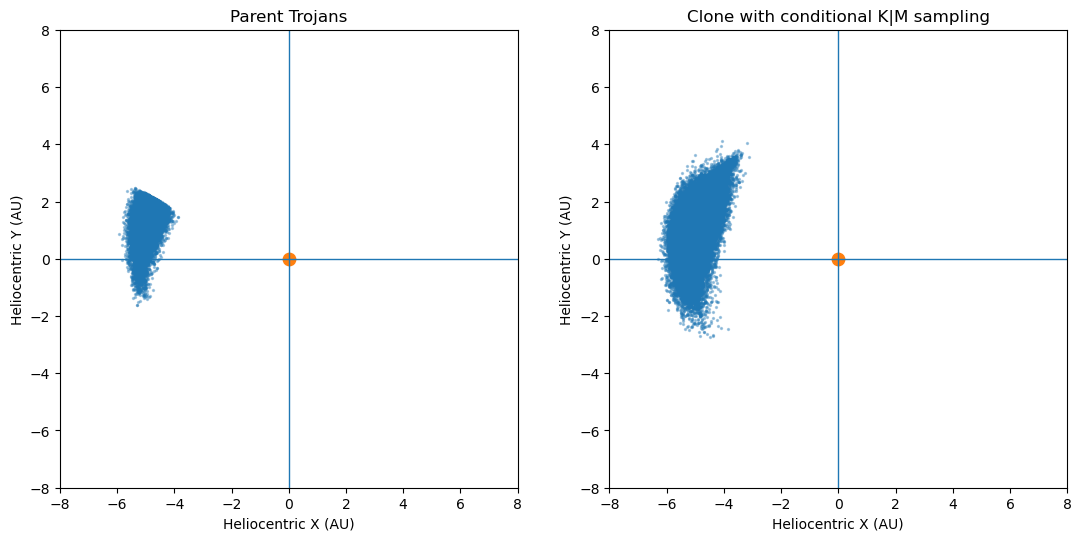

In [55]:
x_clone_new, y_clone_new = elements_to_heliocentric_xy(
    a_rep, e_rep, inc_rep, raan_new, argp_new, tp_out,
    obstime_str=obstime_str,
)

x_parent, y_parent = elements_to_heliocentric_xy(
    trojan_visible["a"].to_numpy(),
    trojan_visible["e"].to_numpy(),
    trojan_visible["i"].to_numpy(),
    trojan_visible["node"].to_numpy(),
    trojan_visible["argperi"].to_numpy(),
    trojan_visible["t_p"].to_numpy(),
    obstime_str=obstime_str,
)

plot_xy_comparison(
    x_parent, y_parent,
    x_clone_new, y_clone_new,
    title1="Parent Trojans",
    title2="Clone with conditional K|M sampling",
)

In [60]:
clone_df = pd.DataFrame({
    "a": a_rep2,
    "e": e_rep2,
    "i": inc_rep2,
    "node": raan_rep2,
    "argperi": argp_rep2,
    "t_p": tp_out2,
})

In [61]:
clone_visible = build_visible_subset_dataframe(
    clone_df,
    obstime_str=obstime_str,
    scorer=scorer_tjn_s3m,
    max_sep_deg=max_sep_deg,
    center_mode="custom_ecliptic",
    center_lon_deg=180.0,
    center_lat_deg=0.0,
)

Propagate with newton: 100%|██████████| 3/3 [00:00<00:00, 22.60it/s]


Propagate with newton: 100%|██████████| 2/2 [00:00<00:00, 17.21it/s]


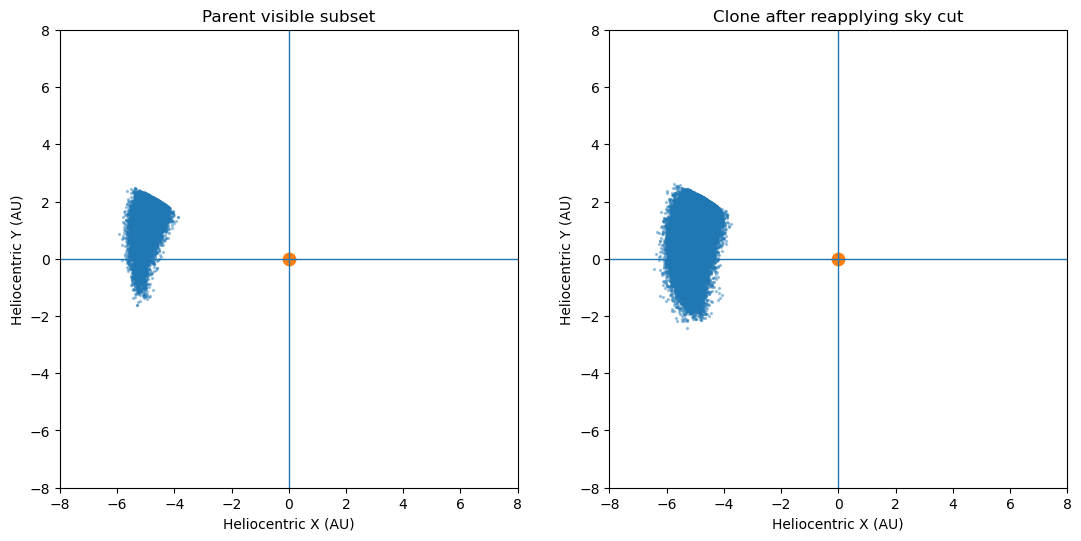

In [62]:
x_parent, y_parent = elements_to_heliocentric_xy(
    trojan_visible["a"].to_numpy(),
    trojan_visible["e"].to_numpy(),
    trojan_visible["i"].to_numpy(),
    trojan_visible["node"].to_numpy(),
    trojan_visible["argperi"].to_numpy(),
    trojan_visible["t_p"].to_numpy(),
    obstime_str=obstime_str,
)

x_clone_cut, y_clone_cut = elements_to_heliocentric_xy(
    clone_visible["a"].to_numpy(),
    clone_visible["e"].to_numpy(),
    clone_visible["i"].to_numpy(),
    clone_visible["node"].to_numpy(),
    clone_visible["argperi"].to_numpy(),
    clone_visible["t_p"].to_numpy(),
    obstime_str=obstime_str,
)

plot_xy_comparison(
    x_parent, y_parent,
    x_clone_cut, y_clone_cut,
    title1="Parent visible subset",
    title2="Clone after reapplying sky cut",
)

In [64]:
print("Parent visible:", len(trojan_visible))
print("Clone visible:", len(clone_visible))

Parent visible: 23605
Clone visible: 185641
